## Installing and Importing Libraries

In [3]:
!pip install -q prophet pytorch-forecasting pytorch-lightning shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.3/425.3 kB 11.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 28.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 12.7 MB/s eta 0:00:00


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
import torch
import lightning.pytorch as pl
from pytorch_forecasting import TimeSeriesDataSet
from pytorch_forecasting.models import TemporalFusionTransformer
from pytorch_forecasting.metrics import QuantileLoss
from pytorch_forecasting.data import GroupNormalizer
import shap

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)

## Importing The Dataset

In [5]:
df = pd.read_csv('/kaggle/input/datasets/janneshop/panama/continuous dataset.csv')

In [6]:
df.sample(5)

,datetime,nat_demand,T2M_toc,QV2M_toc,TQL_toc,W2M_toc,T2M_san,QV2M_san,TQL_san,W2M_san,T2M_dav,QV2M_dav,TQL_dav,W2M_dav,Holiday_ID,holiday,school
24933,2017-11-06 22:00:00,1088.9760,26.417474,0.018904,0.006653,10.302712,24.948724,0.019217,0.377075,4.370261,23.136224,0.018072,0.354858,4.757925,16,1,1
46711,2020-05-02 08:00:00,947.2906,28.074701,0.018856,0.096222,27.995247,26.980951,0.019535,0.051102,11.460344,24.793451,0.017567,0.083710,4.209957,0,0,1
13968,2016-08-07 01:00:00,1061.7797,26.871454,0.020472,0.089355,9.732357,24.918329,0.018984,0.060867,4.857919,23.387079,0.018175,0.058548,3.549335,0,0,1
237,2015-01-12 22:00:00,1113.0861,26.193842,0.019024,0.023537,18.034600,24.334467,0.017673,0.037964,6.225846,23.225092,0.017002,0.109497,3.405555,0,0,0
12381,2016-06-01 22:00:00,1070.6455,27.490076,0.018151,0.019791,1.395960,25.224451,0.019395,0.181152,5.247117,23.771326,0.018853,0.067841,6.247372,0,0,1


## Data Preprocessing and Feature Engineering

In [7]:
df = df.rename(columns={
    "datetime": "timestamp",
    "nat_demand": "load",

    "T2M_toc": "temp_toc",
    "QV2M_toc": "humidity_toc",
    "TQL_toc": "cloud_toc",
    "W2M_toc": "wind_toc",

    "T2M_san": "temp_san",
    "QV2M_san": "humidity_san",
    "TQL_san": "cloud_san",
    "W2M_san": "wind_san",

    "T2M_dav": "temp_dav",
    "QV2M_dav": "humidity_dav",
    "TQL_dav": "cloud_dav",
    "W2M_dav": "wind_dav"
})

In [8]:
df.sample()

,timestamp,load,temp_toc,humidity_toc,cloud_toc,wind_toc,temp_san,humidity_san,cloud_san,wind_san,temp_dav,humidity_dav,cloud_dav,wind_dav,Holiday_ID,holiday,school
1624,2015-03-11 17:00:00,1274.8719,29.963495,0.0168,0.019226,23.312102,32.650995,0.015316,0.029503,13.462447,28.338495,0.01606,0.068695,2.275486,0,0,1


In [9]:
df['timestamp'] = pd.to_datetime(df['timestamp'], format='%Y-%m-%d %H:%M:%S')
df = df.sort_values('timestamp').reset_index(drop=True)
df.head()

,timestamp,load,temp_toc,humidity_toc,cloud_toc,wind_toc,temp_san,humidity_san,cloud_san,wind_san,temp_dav,humidity_dav,cloud_dav,wind_dav,Holiday_ID,holiday,school
0,2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0
1,2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0
2,2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0
3,2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0
4,2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0


In [10]:
#Rebuild calendar features on the hourly grid


df['month'] = df['timestamp'].dt.month
df["is_weekend"] = df["timestamp"].dt.dayofweek.isin([5, 6]).astype(int)

def get_season(month):
    if month in [12,1,2]: return 'Winter'
    elif month in [3,4,5]: return 'Spring'
    elif month in [6,7,8]: return 'Summer'
    else: return 'Fall'
df['season'] = df['month'].apply(get_season)
df.sample(5)

,timestamp,load,temp_toc,humidity_toc,cloud_toc,wind_toc,temp_san,humidity_san,cloud_san,wind_san,temp_dav,humidity_dav,cloud_dav,wind_dav,Holiday_ID,holiday,school,month,is_weekend,season
7314,2015-11-03 19:00:00,1060.3765,25.987848,0.018869,0.134827,5.745460,24.753473,0.018640,0.186035,4.261315,23.472223,0.018152,0.380371,3.681453,14,1,1,11,0,Fall
39386,2019-07-02 03:00:00,953.5074,26.649347,0.019876,0.169373,10.268683,24.789972,0.018762,0.125610,2.376627,23.352472,0.018014,0.197632,2.660688,0,0,1,7,0,Summer
14886,2016-09-14 07:00:00,1075.7412,26.651727,0.017618,0.009781,2.156699,25.339227,0.018602,0.021080,4.836981,23.057977,0.017412,0.138306,3.074507,0,0,0,9,0,Fall
1480,2015-03-05 17:00:00,1281.9234,30.867242,0.015582,0.002730,17.860309,33.601617,0.013030,0.023331,8.492008,28.882867,0.014602,0.052292,2.619782,0,0,1,3,0,Spring
29857,2018-05-31 02:00:00,1051.1972,26.945001,0.020128,0.135437,11.334199,24.710626,0.018747,0.084167,1.709018,23.085626,0.017603,0.080078,2.060260,0,0,1,5,0,Spring


In [12]:
df.sample()

,timestamp,load,temp_toc,humidity_toc,cloud_toc,wind_toc,temp_san,humidity_san,cloud_san,wind_san,temp_dav,humidity_dav,cloud_dav,wind_dav,Holiday_ID,holiday,school,month,is_weekend,season
36088,2019-02-14 17:00:00,1296.9776,28.453271,0.015611,0.012478,20.589191,31.875146,0.014368,0.005985,10.782978,29.484521,0.013883,0.019951,0.899327,0,0,0,2,0,Winter


In [11]:
#Checking for missing values

df.isnull().sum()

timestamp       0
load            0
temp_toc        0
humidity_toc    0
cloud_toc       0
wind_toc        0
temp_san        0
humidity_san    0
cloud_san       0
wind_san        0
temp_dav        0
humidity_dav    0
cloud_dav       0
wind_dav        0
Holiday_ID      0
holiday         0
school          0
month           0
is_weekend      0
season          0
dtype: int64

In [13]:
# cyclical encodings so hour 23 and hour 0 are "close"

df['hour_sin'] = np.sin(2 * np.pi * df['timestamp'].dt.hour / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['timestamp'].dt.hour / 24)

df['month_sin'] = np.sin(2 * np.pi * df['timestamp'].dt.month / 12)
df['month_cos'] = np.cos(2 * np.pi * df['timestamp'].dt.month / 12)

df.head()

,timestamp,load,temp_toc,humidity_toc,cloud_toc,wind_toc,temp_san,humidity_san,cloud_san,wind_san,temp_dav,humidity_dav,cloud_dav,wind_dav,Holiday_ID,holiday,school,month,is_weekend,season,hour_sin,hour_cos,month_sin,month_cos
0,2015-01-03 01:00:00,970.3450,25.865259,0.018576,0.016174,21.850546,23.482446,0.017272,0.001855,10.328949,22.662134,0.016562,0.096100,5.364148,0,0,0,1,1,Winter,0.258819,0.965926,0.5,0.866025
1,2015-01-03 02:00:00,912.1755,25.899255,0.018653,0.016418,22.166944,23.399255,0.017265,0.001327,10.681517,22.578943,0.016509,0.087646,5.572471,0,0,0,1,1,Winter,0.500000,0.866025,0.5,0.866025
2,2015-01-03 03:00:00,900.2688,25.937280,0.018768,0.015480,22.454911,23.343530,0.017211,0.001428,10.874924,22.531030,0.016479,0.078735,5.871184,0,0,0,1,1,Winter,0.707107,0.707107,0.5,0.866025
3,2015-01-03 04:00:00,889.9538,25.957544,0.018890,0.016273,22.110481,23.238794,0.017128,0.002599,10.518620,22.512231,0.016487,0.068390,5.883621,0,0,0,1,1,Winter,0.866025,0.500000,0.5,0.866025
4,2015-01-03 05:00:00,893.6865,25.973840,0.018981,0.017281,21.186089,23.075403,0.017059,0.001729,9.733589,22.481653,0.016456,0.064362,5.611724,0,0,0,1,1,Winter,0.965926,0.258819,0.5,0.866025


In [14]:
# Adding lags as Features

df['lag_1'] = df['load'].shift(1)
df['lag_24'] = df['load'].shift(24)
df['lag_168'] = df['load'].shift(168)  # same hour last week


df = df.dropna().reset_index(drop=True)
df.head()

,timestamp,load,temp_toc,humidity_toc,cloud_toc,wind_toc,temp_san,humidity_san,cloud_san,wind_san,temp_dav,humidity_dav,cloud_dav,wind_dav,Holiday_ID,holiday,school,month,is_weekend,season,hour_sin,hour_cos,month_sin,month_cos,lag_1,lag_24,lag_168
0,2015-01-10 01:00:00,906.9580,24.976495,0.017215,0.025253,21.335333,23.554620,0.016421,0.051376,12.485627,22.288995,0.015735,0.121826,6.229961,0,0,0,1,1,Winter,0.258819,0.965926,0.5,0.866025,949.5031,943.6081,970.3450
1,2015-01-10 02:00:00,863.5135,24.906274,0.017337,0.034378,22.177057,23.429712,0.016337,0.038712,12.949576,22.296899,0.015712,0.117706,6.395434,0,0,0,1,1,Winter,0.500000,0.866025,0.5,0.866025,906.9580,917.0640,912.1755
2,2015-01-10 03:00:00,848.4447,24.879724,0.017512,0.045349,22.742188,23.309412,0.016292,0.028526,13.091533,22.325037,0.015704,0.123718,6.426799,0,0,0,1,1,Winter,0.707107,0.707107,0.5,0.866025,863.5135,895.9092,900.2688
3,2015-01-10 04:00:00,839.8821,24.907922,0.017673,0.047501,22.630025,23.306360,0.016337,0.016182,13.050650,22.368860,0.015704,0.123779,6.351922,0,0,0,1,1,Winter,0.866025,0.500000,0.5,0.866025,848.4447,885.2720,889.9538
4,2015-01-10 05:00:00,847.1073,24.932520,0.017795,0.036087,21.731658,23.354395,0.016422,0.009590,12.846088,22.424707,0.015735,0.118378,6.165582,0,0,0,1,1,Winter,0.965926,0.258819,0.5,0.866025,839.8821,884.8111,893.6865


## Exploratory Data Analysis(EDA)

In [15]:
# Descriptive statistics on key features
desc_cols = ['load', 'temp_toc','humidity_toc','cloud_toc','wind_toc','temp_san','humidity_san','cloud_san','wind_san','temp_dav','humidity_dav','cloud_dav','wind_dav']

desc_stats = df[desc_cols].agg(['min','max','mean','std']).T
desc_stats['CV'] = desc_stats['std'] / desc_stats['mean']
desc_stats

,min,max,mean,std,CV
load,85.192500,1754.882000,1183.187317,192.076742,0.162338
temp_toc,22.953455,35.039575,27.400464,1.674559,0.061114
humidity_toc,0.012054,0.022690,0.018315,0.001609,0.087845
cloud_toc,0.000000,0.521240,0.080203,0.065591,0.817809
wind_toc,0.008979,39.229726,13.349231,7.270045,0.544604
temp_san,19.765222,39.063440,26.924994,3.018298,0.112100
humidity_san,0.010247,0.022165,0.017846,0.001891,0.105945
cloud_san,0.000009,0.484985,0.106561,0.086293,0.809800
wind_san,0.060394,24.483937,7.024528,4.088421,0.582021
temp_dav,19.933740,34.216211,24.722584,2.414794,0.097676


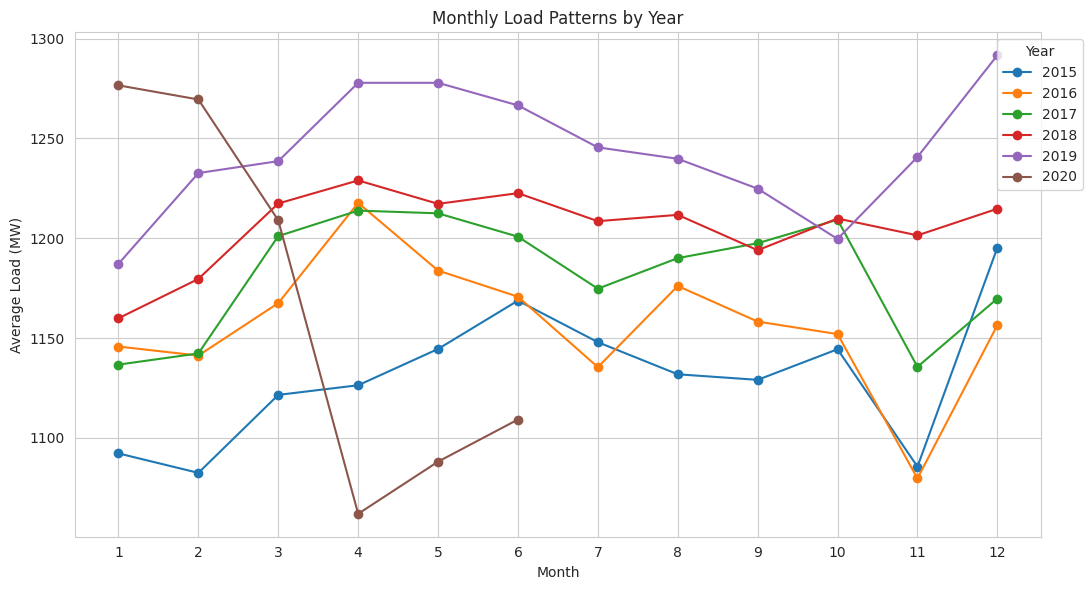

In [16]:
df['year'] = df['timestamp'].dt.year
monthly_avg = df.groupby(['year','month'])['load'].mean().reset_index()

plt.figure(figsize=(12,6))
for yr in monthly_avg['year'].unique():
    sub = monthly_avg[monthly_avg['year']==yr]
    plt.plot(sub['month'], sub['load'], marker='o', label=yr)
plt.xlabel('Month'); plt.ylabel('Average Load (MW)')
plt.xticks(range(1,13))  # force all months 1–12
plt.title('Monthly Load Patterns by Year')
plt.legend(title='Year', bbox_to_anchor=(1.05,1))
plt.tight_layout(); plt.show()

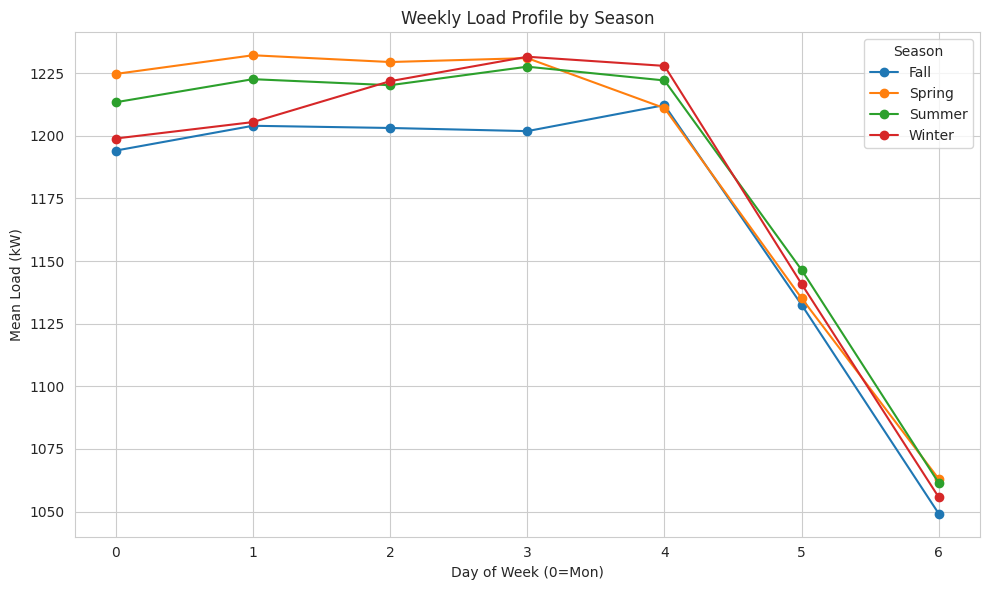

In [17]:
df['day_of_week'] = df['timestamp'].dt.dayofweek
season_dow = df.groupby(['season','day_of_week'])['load'].mean().reset_index()

plt.figure(figsize=(10,6))

for s in season_dow['season'].unique():
    sub = season_dow[season_dow['season']==s]
    plt.plot(sub['day_of_week'], sub['load'], marker='o', label=s)

plt.xlabel('Day of Week (0=Mon)')
plt.ylabel('Mean Load (kW)')
plt.title('Weekly Load Profile by Season')
plt.legend(title='Season')
plt.tight_layout()
plt.show()

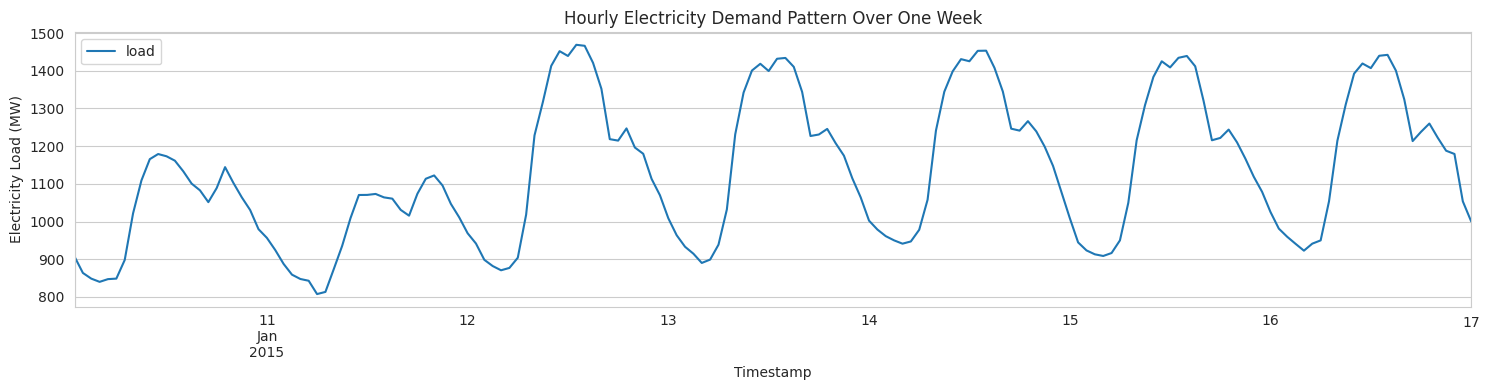

In [18]:
week = df.iloc[:24*7]

week.plot(
    x='timestamp',
    y='load',
    kind='line',
    figsize=(15,4)
)

plt.title("Hourly Electricity Demand Pattern Over One Week")
plt.xlabel("Timestamp")
plt.ylabel("Electricity Load (MW)")
plt.tight_layout()
plt.show()

<Axes: xlabel='hour_of_day'>

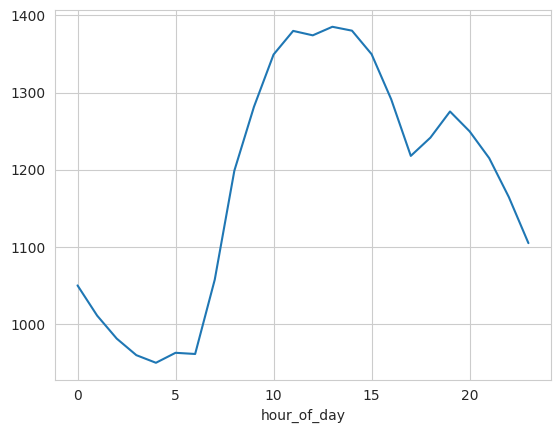

In [19]:
#Plot average load demand by hour of day
df['hour_of_day'] = df['timestamp'].dt.hour


df.groupby('hour_of_day')['load'].mean().plot()

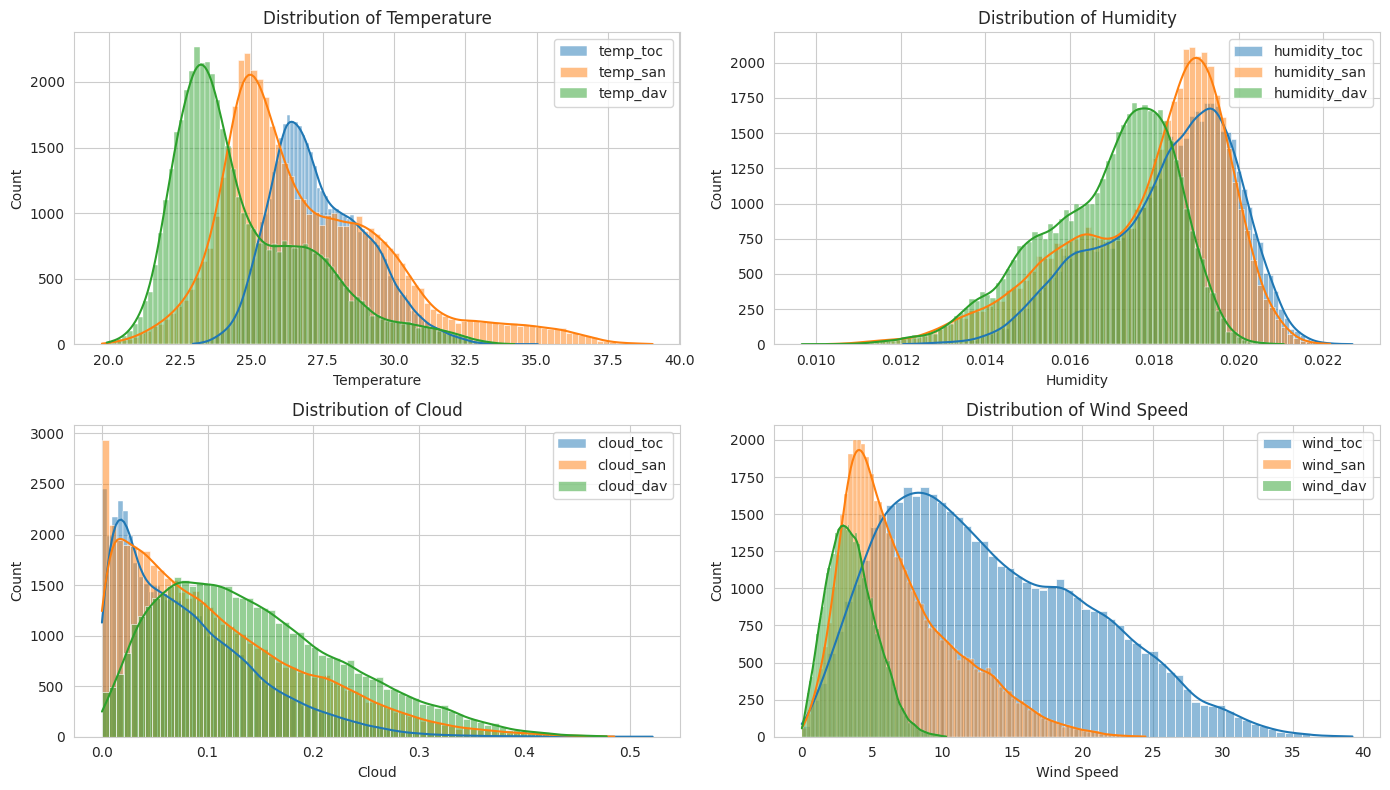

In [21]:
#Distribution of Weather Parameters across the regions

import matplotlib.pyplot as plt
import seaborn as sns

weather_groups = {
    "Temperature": ['temp_toc', 'temp_san', 'temp_dav'],
    "Humidity": ['humidity_toc', 'humidity_san', 'humidity_dav'],
    "Cloud": ['cloud_toc', 'cloud_san', 'cloud_dav'],
    "Wind Speed": ['wind_toc', 'wind_san', 'wind_dav']
}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, (title, cols) in zip(axes.flat, weather_groups.items()):
    for col in cols:
        sns.histplot(
            df[col],
            kde=True,
            ax=ax,
            label=col
        )

    ax.set_title(f"Distribution of {title}")
    ax.set_xlabel(title)
    ax.legend()

plt.tight_layout()
plt.show()

In [22]:
#Outlier Detection using IQR
Q1 = df['load'].quantile(0.25)
Q3 = df['load'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 3.5*IQR
upper = Q3 + 3.0*IQR

n_before = len(df)
df = df[(df['load'] >= lower) & (df['load'] <= upper)].reset_index(drop=True)
print(f"Removed {n_before - len(df)} outliers ({(n_before-len(df))/n_before*100:.2f}%)")

Removed 0 outliers (0.00%)


In [23]:
#Train Test Split

# Remove pandemic period (2020)
df = df[df['timestamp'].dt.year != 2020].reset_index(drop=True)

cutoff_date = df['timestamp'].quantile(0.8)  # last ~20% as test
train_df = df[df['timestamp'] < cutoff_date].copy()
test_df = df[df['timestamp'] >= cutoff_date].copy()

## Prophet as  Feature Extractor

In [25]:
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')  # Prophet is noisy with cmdstanpy logs

def generate_rolling_prophet_features(df, date_col='timestamp', target_col='load',
                                        min_train_days=180, step_days=28,
                                        country_holidays='PA'):
    """
    - Refit Prophet at each rolling origin using only past data
    - Generate trend/seasonality for the next `step_days` window only
    - Never let Prophet see data beyond the current origin
    """
    df = df.sort_values(date_col).reset_index(drop=True)
    start_date = df[date_col].min() + pd.Timedelta(days=min_train_days)
    end_date = df[date_col].max()
    origins = pd.date_range(start_date, end_date, freq=f'{step_days}D')

    all_feature_rows = []

    for i, origin in enumerate(origins):
        window_end = origins[i+1] if i+1 < len(origins) else end_date + pd.Timedelta(hours=1)

        train_slice = df[df[date_col] < origin]
        target_slice = df[(df[date_col] >= origin) & (df[date_col] < window_end)]

        if len(train_slice) < min_train_days*24 or len(target_slice) == 0:
            continue

        m = Prophet(
            seasonality_mode='multiplicative',
            daily_seasonality=True,
            weekly_seasonality=True,
            yearly_seasonality=True,
            changepoint_prior_scale=0.1,
            seasonality_prior_scale=10
        )
        if country_holidays:
            m.add_country_holidays(country_name=country_holidays)

        prophet_train = train_slice[[date_col, target_col]].rename(columns={date_col:'ds', target_col:'y'})
        m.fit(prophet_train)

        fc_input = target_slice[[date_col]].rename(columns={date_col:'ds'})
        fc = m.predict(fc_input)

        result = pd.DataFrame({
            date_col: target_slice[date_col].values,
            'prophet_trend': fc['trend'].values,
            'prophet_seasonality': (fc['yearly'] + fc['weekly'] + fc['daily']).values
        })
        all_feature_rows.append(result)

        if i % 5 == 0:
            print(f"Fold {i+1}/{len(origins)} done — origin {origin.date()}, "
                  f"train size {len(train_slice)}, target size {len(target_slice)}")

    return pd.concat(all_feature_rows).reset_index(drop=True)

prophet_features = generate_rolling_prophet_features(
    df, date_col='timestamp', target_col='load',
    min_train_days=180,   # need at least ~6 months of history before first fold
    step_days=28,         # prediction window size
    country_holidays='PA'
)

print(prophet_features.shape)
prophet_features.head()

15:56:47 - cmdstanpy - INFO - Chain [1] start processing
15:56:53 - cmdstanpy - INFO - Chain [1] done processing


Fold 1/59 done — origin 2015-07-09, train size 4320, target size 672


15:56:54 - cmdstanpy - INFO - Chain [1] start processing
15:56:58 - cmdstanpy - INFO - Chain [1] done processing
15:56:59 - cmdstanpy - INFO - Chain [1] start processing
15:57:07 - cmdstanpy - INFO - Chain [1] done processing
15:57:08 - cmdstanpy - INFO - Chain [1] start processing
15:57:09 - cmdstanpy - INFO - Chain [1] done processing
15:57:10 - cmdstanpy - INFO - Chain [1] start processing
15:57:15 - cmdstanpy - INFO - Chain [1] done processing
15:57:16 - cmdstanpy - INFO - Chain [1] start processing
15:57:17 - cmdstanpy - INFO - Chain [1] done processing


Fold 6/59 done — origin 2015-11-26, train size 7680, target size 672


15:57:18 - cmdstanpy - INFO - Chain [1] start processing
15:57:20 - cmdstanpy - INFO - Chain [1] done processing
15:57:20 - cmdstanpy - INFO - Chain [1] start processing
15:57:24 - cmdstanpy - INFO - Chain [1] done processing
15:57:24 - cmdstanpy - INFO - Chain [1] start processing
15:57:29 - cmdstanpy - INFO - Chain [1] done processing
15:57:30 - cmdstanpy - INFO - Chain [1] start processing
15:57:33 - cmdstanpy - INFO - Chain [1] done processing
15:57:34 - cmdstanpy - INFO - Chain [1] start processing
15:57:38 - cmdstanpy - INFO - Chain [1] done processing


...

16:10:11 - cmdstanpy - INFO - Chain [1] start processing
16:10:51 - cmdstanpy - INFO - Chain [1] done processing
16:10:53 - cmdstanpy - INFO - Chain [1] start processing
16:11:27 - cmdstanpy - INFO - Chain [1] done processing
16:11:29 - cmdstanpy - INFO - Chain [1] start processing
16:12:18 - cmdstanpy - INFO - Chain [1] done processing
16:12:20 - cmdstanpy - INFO - Chain [1] start processing
16:12:56 - cmdstanpy - INFO - Chain [1] done processing
16:12:58 - cmdstanpy - INFO - Chain [1] start processing
16:13:37 - cmdstanpy - INFO - Chain [1] done processing


Fold 56/59 done — origin 2019-09-26, train size 41280, target size 672


16:13:39 - cmdstanpy - INFO - Chain [1] start processing
16:14:21 - cmdstanpy - INFO - Chain [1] done processing
16:14:23 - cmdstanpy - INFO - Chain [1] start processing
16:15:08 - cmdstanpy - INFO - Chain [1] done processing
16:15:10 - cmdstanpy - INFO - Chain [1] start processing
16:16:03 - cmdstanpy - INFO - Chain [1] done processing


(39287, 3)


,timestamp,prophet_trend,prophet_seasonality
0,2015-07-09 01:00:00,205.583355,3.758952
1,2015-07-09 02:00:00,205.570154,3.679129
2,2015-07-09 03:00:00,205.556954,3.569846
3,2015-07-09 04:00:00,205.543754,3.436437
4,2015-07-09 05:00:00,205.530554,3.404844


In [26]:
df = df.merge(prophet_features, on='timestamp', how='left')

# Rows before the first fold's origin won't have prophet features — drop them
print("Rows missing prophet features:", df['prophet_trend'].isna().sum())
df = df.dropna(subset=['prophet_trend', 'prophet_seasonality']).reset_index(drop=True)

Rows missing prophet features: 4320


## Training the Temporal Fusion Transformer(TFT)

In [27]:
df['time_idx'] = (df['timestamp'] - df['timestamp'].min()).dt.total_seconds() // 3600
df['time_idx'] = df['time_idx'].astype(int)
df['series_id'] = 'main'  # single series; needed by pytorch-forecasting

max_encoder_length = 168   # 1 week lookback
max_prediction_length = 24 # forecast next 24 hours

# 70% train, 15% val, 15% test
n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end]
val_df = df.iloc[train_end:val_end]
test_df = df.iloc[val_end:]

print(f"Train: {train_df['timestamp'].min()} to {train_df['timestamp'].max()}")
print(f"Val:   {val_df['timestamp'].min()} to {val_df['timestamp'].max()}")
print(f"Test:  {test_df['timestamp'].min()} to {test_df['timestamp'].max()}")


train_cutoff = train_df['time_idx'].max()
val_cutoff = val_df['time_idx'].max()
print(train_cutoff)
print(val_cutoff)

training = TimeSeriesDataSet(
    df[df['time_idx'] <= train_cutoff],
    time_idx='time_idx',
    target='load',
    group_ids=['series_id'],
    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,
    static_categoricals=['series_id'],
    time_varying_known_reals=[
    'time_idx',
    'hour_sin',
    'hour_cos',
    'month_sin',
    'month_cos',
    'day_of_week',
    'is_weekend',
    'holiday',
    'prophet_trend',
    'prophet_seasonality'
],
    time_varying_unknown_reals=[
         'load',

         # Historical load patterns
         'lag_1',
         'lag_24',
         'lag_168',

         # Historical weather observations
         'temp_toc',
         'humidity_toc',
         'cloud_toc',
         'wind_toc',

         'temp_san',
         'humidity_san',
         'cloud_san',
         'wind_san',

         'temp_dav',
         'humidity_dav',
         'cloud_dav',
         'wind_dav'
        ]
    ,
    target_normalizer=GroupNormalizer(groups=['series_id']),
    add_relative_time_idx=True,
    add_target_scales=True,
)

validation = TimeSeriesDataSet.from_dataset(
    training,
    df[(df['time_idx'] > train_cutoff - max_encoder_length) & (df['time_idx'] <= val_cutoff)],
    predict=False,
    stop_randomization=True
)
print("Validation samples:", len(validation))
test_dataset = TimeSeriesDataSet.from_dataset(
    training,
    df[df['time_idx'] > val_cutoff - max_encoder_length],
    predict=False,
    stop_randomization=True
)
print("Test samples:", len(test_dataset))

batch_size = 64
train_dataloader = training.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
val_dataloader = validation.to_dataloader(train=False, batch_size=batch_size, num_workers=0)
test_dataloader = test_dataset.to_dataloader(train=False, batch_size=batch_size, num_workers=0)

Train: 2015-07-09 01:00:00 to 2018-08-27 20:00:00
Val:   2018-08-27 21:00:00 to 2019-04-30 09:00:00
Test:  2019-04-30 10:00:00 to 2019-12-31 23:00:00
27499
33392
Validation samples: 5870
Test samples: 5871


In [28]:

all_preds = []

for seed in [42, 123, 7]:

    # Set random seed
    pl.seed_everything(seed)

    # Create a fresh TFT model
    tft = TemporalFusionTransformer.from_dataset(
        training,
        learning_rate=0.001,
        hidden_size=64,
        attention_head_size=4,
        dropout=0.25,
        hidden_continuous_size=16,
        output_size=3,
        loss=QuantileLoss(quantiles=[0.1, 0.5, 0.9]),
        log_interval=10,
        reduce_on_plateau_patience=5,
    )

    # New callbacks for this run
    checkpoint_callback = pl.callbacks.ModelCheckpoint(
        dirpath=f"checkpoints_seed_{seed}/",
        filename="best-tft-{epoch}-{val_loss:.2f}",
        monitor="val_loss",
        mode="min",
        save_top_k=1,
    )

    early_stop = pl.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        mode="min",
    )

    trainer = pl.Trainer(
        max_epochs=30,
        accelerator="auto",
        gradient_clip_val=0.1,
        callbacks=[early_stop, checkpoint_callback],
    )

    trainer.fit(
        tft,
        train_dataloaders=train_dataloader,
        val_dataloaders=val_dataloader,
    )

    preds = tft.predict(test_dataloader, mode="prediction").cpu().numpy()
    all_preds.append(preds)

# Average predictions from all models
ensemble_pred = np.mean(all_preds, axis=0)


Seed set to 42
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │      1 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    928 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  6.5 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 98.8 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 36.9 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │ 33.3 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │ 33.3 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  8.3 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    128 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │ 20.9 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │ 10.4 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    195 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 348 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 348 K                                                                                                
Total estimated model params size (MB): 1.396                                                                      
Modules in train mode: 755                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Seed set to 123
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but

...

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
Seed set to 7
Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but p

┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │      1 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    928 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  6.5 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │ 98.8 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 36.9 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │ 33.3 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │ 33.3 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │  8.3 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    128 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │ 20.9 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │ 10.4 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │ 16.8 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │  8.4 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    195 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 348 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 348 K                                                                                                
Total estimated model params size (MB): 1.396                                                                      
Modules in train mode: 755                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


In [29]:
# Load the best checkpoint, not whatever's currently in memory
best_model_path = checkpoint_callback.best_model_path
tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)
print("Best checkpoint:", best_model_path)

import shutil

shutil.copy(best_model_path, "/kaggle/working/tft_best.ckpt")

Best checkpoint: /kaggle/working/checkpoints_seed_7/best-tft-epoch=3-val_loss=19.67.ckpt


'/kaggle/working/tft_best.ckpt'

## Evaluating Our Prophet + TFT Model

In [30]:
predictions = tft.predict(
    test_dataset,
    mode="prediction",
    return_x=True
)

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


In [31]:
raw_predictions = tft.predict(test_dataset, mode="raw", return_x=True)

y_pred_median = predictions.output.numpy().flatten()  # P50 forecast
y_true = np.concatenate([x['decoder_target'].numpy() for x in [predictions.x]]).flatten()

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


In [32]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)

mae = mean_absolute_error(y_true, y_pred_median)
mse = mean_squared_error(y_true, y_pred_median)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_true, y_pred_median) * 100

print(f"MAE:  {mae:.2f} MW")
print(f"MSE:  {mse:.2f} MW²")
print(f"RMSE: {rmse:.2f} MW")
print(f"MAPE: {mape:.2f} %")
print(f"Approx. Accuracy: {100 - mape:.2f}%")

MAE:  48.12 MW
MSE:  3859.56 MW²
RMSE: 62.13 MW
MAPE: 3.80 %
Approx. Accuracy: 96.20%


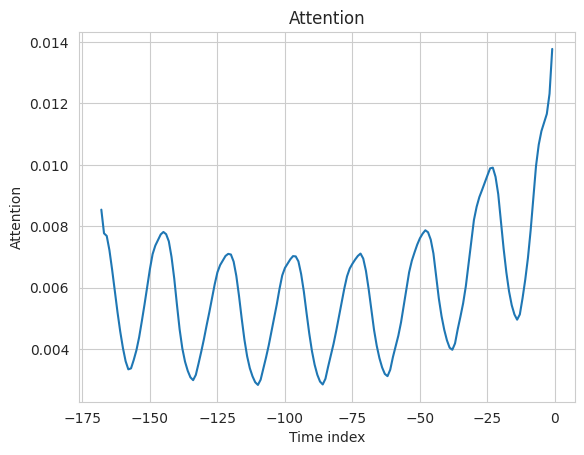

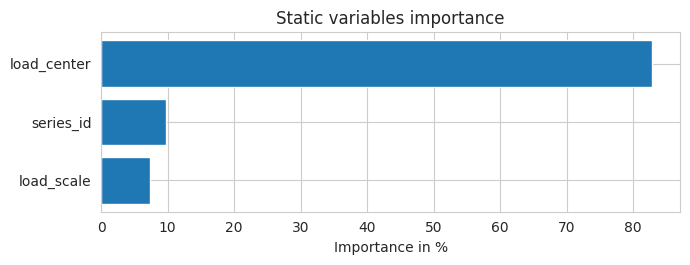

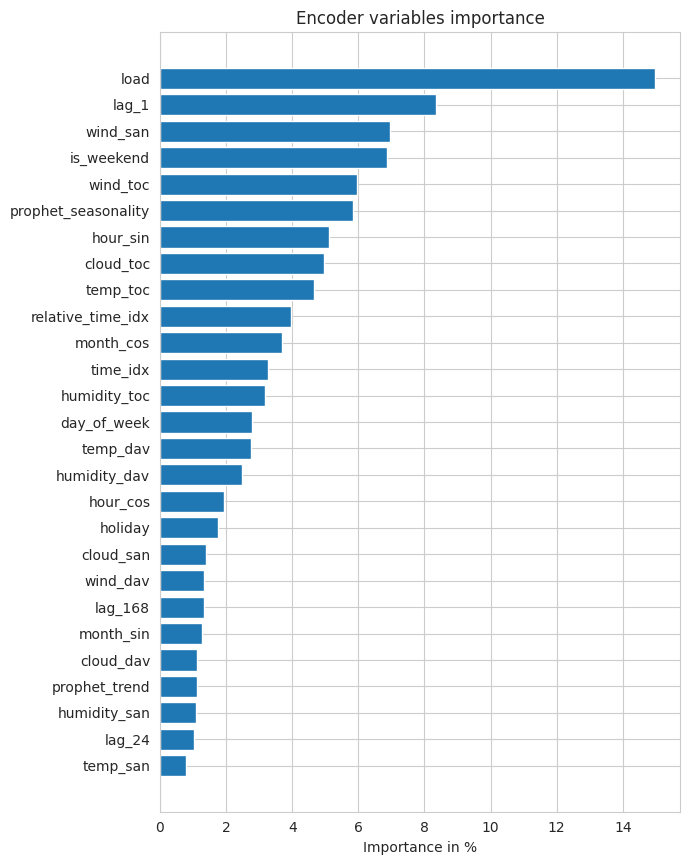

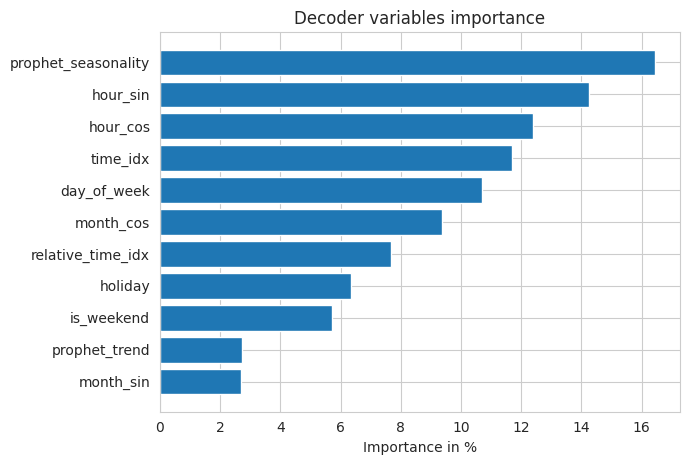

In [33]:
interpretation = tft.interpret_output(raw_predictions.output, reduction="sum")
tft.plot_interpretation(interpretation)
plt.show()

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


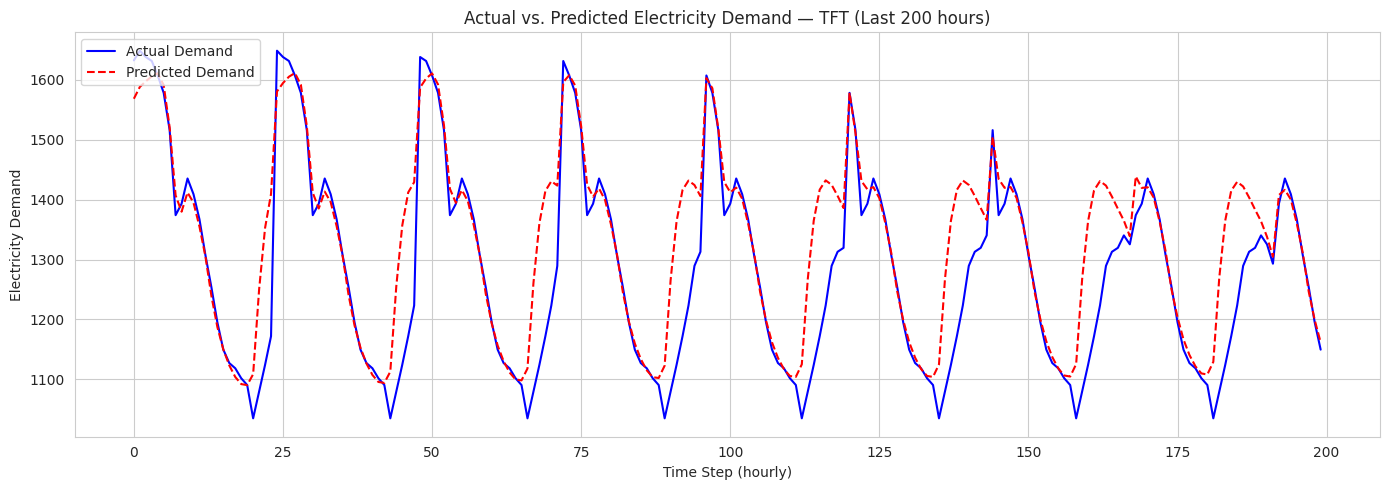

In [70]:
# Using your existing test-set predictions from the TFT
predictions = tft.predict(test_dataloader, mode="prediction", return_x=True)
y_pred_tft = predictions.output.cpu().numpy().flatten()
y_true_tft = predictions.x['decoder_target'].cpu().numpy().flatten()

n_hours = 200

plt.figure(figsize=(14, 5))
plt.plot(range(n_hours), y_true_tft[:n_hours], color='blue', linewidth=1.5, label='Actual Demand')
plt.plot(range(n_hours), y_pred_tft[:n_hours], color='red', linewidth=1.5, linestyle='--', label='Predicted Demand')
plt.xlabel('Time Step (hourly)')
plt.ylabel('Electricity Demand')
plt.title('Actual vs. Predicted Electricity Demand — TFT (Last 200 hours)')
plt.legend(loc='upper left')
plt.tight_layout()
plt.savefig('actual_vs_predicted_tft.png', dpi=150, bbox_inches='tight')
plt.show()

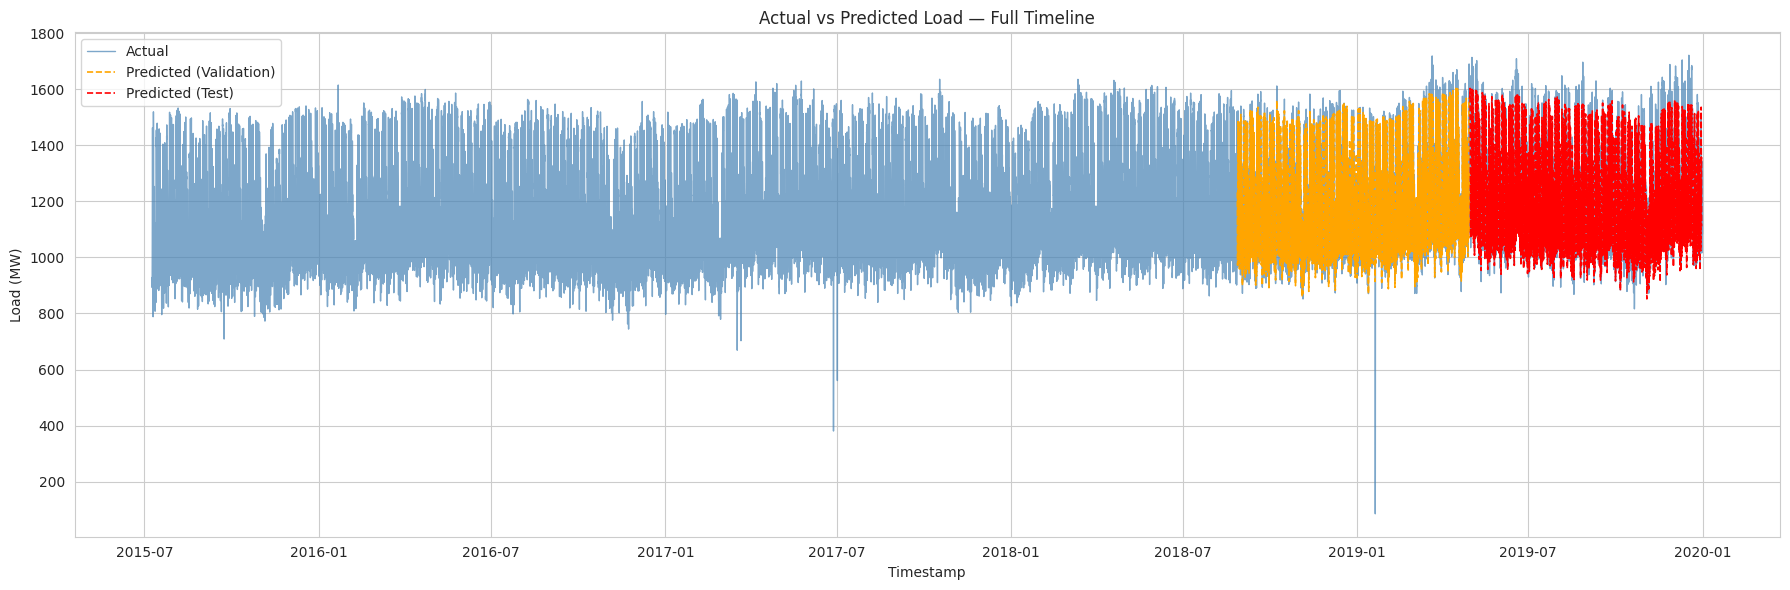

In [85]:
# actual (whole timeline) vs predicted (val in yellow, test in red)
fig, ax = plt.subplots(figsize=(18, 6))

ax.plot(actual_plot_df['timestamp'], actual_plot_df['value'], color='steelblue', linewidth=1, label='Actual', alpha=0.7)
ax.plot(val_plot_df['timestamp'], val_plot_df['value'], color='orange', linewidth=1.2, linestyle='--', label='Predicted (Validation)')
ax.plot(test_plot_df['timestamp'], test_plot_df['value'], color='red', linewidth=1.2, linestyle='--', label='Predicted (Test)')

ax.set_xlabel('Timestamp')
ax.set_ylabel('Load (MW)')
ax.set_title('Actual vs Predicted Load — Full Timeline')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('actual_vs_predicted_full_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

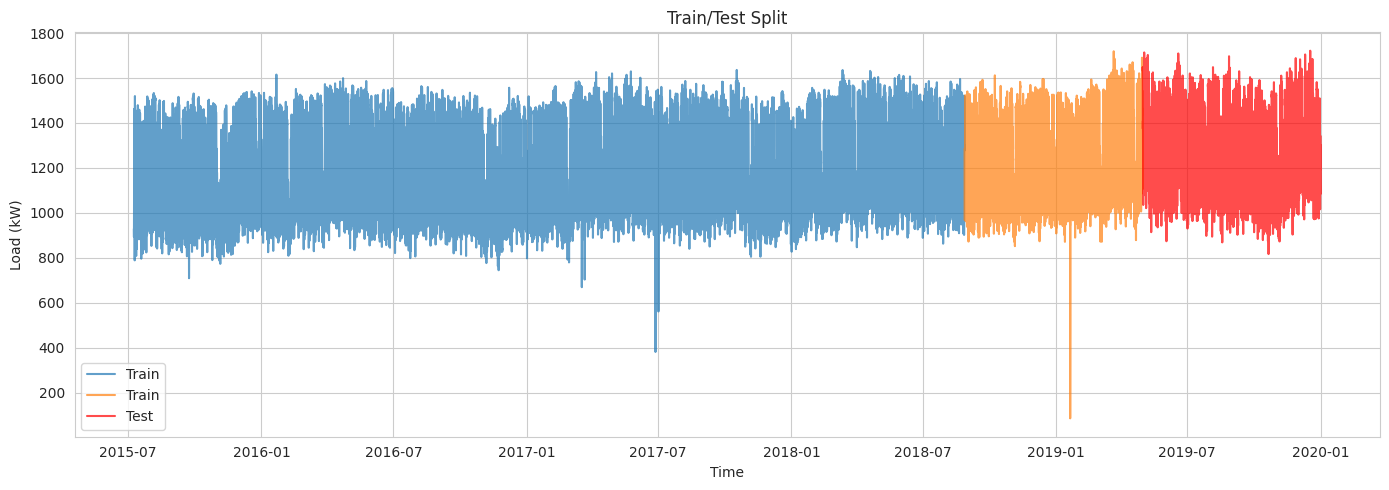

Train: 27500 rows | Test: 5894 rows


In [79]:
plt.figure(figsize=(14,5))
plt.plot(train_df['timestamp'], train_df['load'], label='Train', alpha=0.7)
plt.plot(val_df['timestamp'], val_df['load'], label='Train', alpha=0.7)
plt.plot(test_df['timestamp'], test_df['load'], label='Test', alpha=0.7, color='red')
plt.legend(); plt.title('Train/Test Split'); plt.xlabel('Time'); plt.ylabel('Load (kW)')
plt.tight_layout(); plt.show()

print(f"Train: {len(train_df)} rows | Test: {len(test_df)} rows")